# Ingesta y preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("apartments_pl_2023_08.csv")

In [ ]:
df

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,0.413,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,...,0.205,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,...,0.280,condominium,brick,NaN,no,no,no,no,no,565000
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,...,0.087,condominium,brick,NaN,yes,yes,no,no,yes,640000
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,...,0.514,condominium,NaN,NaN,no,no,no,no,no,759000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18900,ae88d7ea0a7a5fa0e9d287cfd78e5676,bydgoszcz,blockOfFlats,84.00,3.0,NaN,4.0,2000.0,53.112927,17.975630,...,0.164,cooperative,brick,NaN,yes,yes,no,no,yes,789000
18901,6a4b30b5fcdee00bfe5bcc0da82df9b1,bydgoszcz,blockOfFlats,94.30,4.0,NaN,2.0,1998.0,53.115921,17.956396,...,0.428,condominium,NaN,NaN,no,yes,no,no,yes,699000
18902,1e7f4f1fdfea31eb84e071d697839632,bydgoszcz,NaN,50.12,2.0,1.0,1.0,NaN,53.126000,18.007900,...,0.205,condominium,brick,NaN,yes,no,no,no,no,360000
18903,d971c4ed3aab9919bf203e96019a678e,bydgoszcz,tenement,100.00,4.0,3.0,4.0,1910.0,53.126000,18.007900,...,0.205,condominium,brick,premium,yes,yes,no,no,yes,590000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18905 entries, 0 to 18904
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    18905 non-null  object 
 1   city                  18905 non-null  object 
 2   type                  14866 non-null  object 
 3   squareMeters          18905 non-null  float64
 4   rooms                 18905 non-null  float64
 5   floor                 15467 non-null  float64
 6   floorCount            18643 non-null  float64
 7   buildYear             15634 non-null  float64
 8   latitude              18905 non-null  float64
 9   longitude             18905 non-null  float64
 10  centreDistance        18905 non-null  float64
 11  poiCount              18905 non-null  float64
 12  schoolDistance        18891 non-null  float64
 13  clinicDistance        18817 non-null  float64
 14  postOfficeDistance    18880 non-null  float64
 15  kindergartenDistanc

In [ ]:
df.columns

Index(['id', 'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'buildYear', 'latitude', 'longitude', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'buildingMaterial', 'condition',
       'hasParkingSpace', 'hasBalcony', 'hasElevator', 'hasSecurity',
       'hasStorageRoom', 'price'],
      dtype='object')

In [ ]:
df.isna().sum().sort_values(ascending=False)/len(df)

condition               0.758741
buildingMaterial        0.390743
type                    0.213647
floor                   0.181857
buildYear               0.173023
hasElevator             0.048982
collegeDistance         0.029886
floorCount              0.013859
clinicDistance          0.004655
restaurantDistance      0.003068
pharmacyDistance        0.001428
postOfficeDistance      0.001322
schoolDistance          0.000741
kindergartenDistance    0.000688
hasParkingSpace         0.000000
ownership               0.000000
hasSecurity             0.000000
hasStorageRoom          0.000000
hasBalcony              0.000000
id                      0.000000
city                    0.000000
poiCount                0.000000
centreDistance          0.000000
longitude               0.000000
latitude                0.000000
rooms                   0.000000
squareMeters            0.000000
price                   0.000000
dtype: float64

In [ ]:
df["condition"].value_counts(dropna=False)

condition
NaN        14344
premium     2426
low         2135
Name: count, dtype: int64

In [ ]:
df["buildingMaterial"].value_counts(dropna=False)

buildingMaterial
brick           8804
NaN             7387
concreteSlab    2714
Name: count, dtype: int64

In [ ]:
df["type"].value_counts(dropna=False)

type
blockOfFlats         9089
NaN                  4039
tenement             2895
apartmentBuilding    2882
Name: count, dtype: int64

In [ ]:
unwanted_columns = ["condition", "buildingMaterial"]
desired_columns = [i for i in list(df.columns) if i not in unwanted_columns]
df = df[desired_columns]
df

,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,restaurantDistance,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,...,1.652,NaN,0.413,condominium,yes,yes,yes,no,yes,415000
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,...,0.348,1.404,0.205,cooperative,no,yes,yes,no,yes,395995
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,...,0.300,1.857,0.280,condominium,no,no,no,no,no,565000
3,0a68cd14c44ec5140143ece75d739535,szczecin,tenement,87.60,3.0,2.0,3.0,NaN,53.435100,14.532900,...,0.101,0.310,0.087,condominium,yes,yes,no,no,yes,640000
4,f66320e153c2441edc0fe293b54c8aeb,szczecin,blockOfFlats,66.00,3.0,1.0,3.0,NaN,53.410278,14.503611,...,0.501,2.138,0.514,condominium,no,no,no,no,no,759000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18900,ae88d7ea0a7a5fa0e9d287cfd78e5676,bydgoszcz,blockOfFlats,84.00,3.0,NaN,4.0,2000.0,53.112927,17.975630,...,0.665,0.985,0.164,cooperative,yes,yes,no,no,yes,789000
18901,6a4b30b5fcdee00bfe5bcc0da82df9b1,bydgoszcz,blockOfFlats,94.30,4.0,NaN,2.0,1998.0,53.115921,17.956396,...,0.088,0.759,0.428,condominium,no,yes,no,no,yes,699000
18902,1e7f4f1fdfea31eb84e071d697839632,bydgoszcz,NaN,50.12,2.0,1.0,1.0,NaN,53.126000,18.007900,...,0.058,0.622,0.205,condominium,yes,no,no,no,no,360000
18903,d971c4ed3aab9919bf203e96019a678e,bydgoszcz,tenement,100.00,4.0,3.0,4.0,1910.0,53.126000,18.007900,...,0.058,0.622,0.205,condominium,yes,yes,no,no,yes,590000


In [ ]:
df["type"] = df["type"].fillna("unknown")

<ipython-input-135-e7bdcc68d52f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["type"] = df["type"].fillna("unknown")


In [ ]:
df = df.dropna()

In [ ]:
df["squareMeters"] = df["squareMeters"].astype("float64")

<ipython-input-137-bb46939388cc>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["squareMeters"] = df["squareMeters"].astype("float64")


In [ ]:
df["hasParkingSpace"].apply(lambda x: 1 if x == "yes" else 0)

5        1
6        0
7        0
8        0
9        1
        ..
18894    1
18895    0
18899    0
18903    1
18904    0
Name: hasParkingSpace, Length: 12045, dtype: int64

In [ ]:
df.dtypes

id                       object
city                     object
type                     object
squareMeters            float64
rooms                   float64
floor                   float64
floorCount              float64
buildYear               float64
latitude                float64
longitude               float64
centreDistance          float64
poiCount                float64
schoolDistance          float64
clinicDistance          float64
postOfficeDistance      float64
kindergartenDistance    float64
restaurantDistance      float64
collegeDistance         float64
pharmacyDistance        float64
ownership                object
hasParkingSpace          object
hasBalcony               object
hasElevator              object
hasSecurity              object
hasStorageRoom           object
price                     int64
dtype: object

In [ ]:
df["years_of_antiguaty"] = df["buildYear"].apply(lambda x: 2024 - x)
df

<ipython-input-140-160b140c38a1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["years_of_antiguaty"] = df["buildYear"].apply(lambda x: 2024 - x)


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,...,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,years_of_antiguaty
5,2e190fcd6934978ca36d86ba41e842fc,szczecin,blockOfFlats,63.30,3.0,2.0,4.0,1997.0,53.463100,14.572800,...,0.377,0.745,cooperative,yes,yes,no,no,yes,499000,27.0
6,ec27024bfcd012728617a35dad2cb6b8,szczecin,blockOfFlats,47.45,2.0,2.0,10.0,1974.0,53.450232,14.562625,...,1.736,0.277,condominium,no,no,yes,no,yes,370000,50.0
7,d3e0e36529df3360849ec40168c10755,szczecin,apartmentBuilding,60.08,2.0,3.0,4.0,2009.0,53.454685,14.551520,...,1.945,0.155,condominium,no,yes,yes,no,no,629000,15.0
8,7e1981e920d763d6237c5bdcf13cf5b7,szczecin,blockOfFlats,47.76,2.0,8.0,12.0,1980.0,53.458869,14.536403,...,1.879,0.420,condominium,no,yes,yes,no,yes,399000,44.0
9,4a04a9c54d8281e3ec23df031e538d85,szczecin,tenement,72.09,4.0,2.0,3.0,1890.0,53.435092,14.559612,...,0.653,0.199,condominium,yes,no,no,no,yes,325000,134.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18894,73d419e114a685f2695836168a127cb5,bydgoszcz,apartmentBuilding,91.00,4.0,2.0,2.0,2015.0,53.124984,18.049752,...,0.861,0.155,condominium,yes,yes,yes,no,no,870000,9.0
18895,908fef6a182cef3ce3fa6a8ba9c34ed8,bydgoszcz,tenement,110.07,4.0,2.0,2.0,1852.0,53.126000,18.007900,...,0.622,0.205,condominium,no,no,no,no,no,510000,172.0
18899,bb19da639a2de8bba49be2ca49053c87,bydgoszcz,tenement,108.96,5.0,2.0,4.0,1889.0,53.126000,18.007900,...,0.622,0.205,condominium,no,no,no,no,yes,795000,135.0
18903,d971c4ed3aab9919bf203e96019a678e,bydgoszcz,tenement,100.00,4.0,3.0,4.0,1910.0,53.126000,18.007900,...,0.622,0.205,condominium,yes,yes,no,no,yes,590000,114.0


In [ ]:
df = df[[
       'city', 'type', 'squareMeters', 'rooms', 'floor', 'floorCount',
       'years_of_antiguaty', 'centreDistance', 'poiCount',
       'schoolDistance', 'clinicDistance', 'postOfficeDistance',
       'kindergartenDistance', 'restaurantDistance', 'collegeDistance',
       'pharmacyDistance', 'ownership', 'hasParkingSpace', 'hasBalcony',
       'hasElevator', 'hasSecurity', 'hasStorageRoom', 'price'
]]
df

,city,type,squareMeters,rooms,floor,floorCount,years_of_antiguaty,centreDistance,poiCount,schoolDistance,...,restaurantDistance,collegeDistance,pharmacyDistance,ownership,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price
5,szczecin,blockOfFlats,63.30,3.0,2.0,4.0,27.0,4.48,10.0,0.079,...,1.102,0.377,0.745,cooperative,yes,yes,no,no,yes,499000
6,szczecin,blockOfFlats,47.45,2.0,2.0,10.0,50.0,2.99,18.0,0.327,...,0.244,1.736,0.277,condominium,no,no,yes,no,yes,370000
7,szczecin,apartmentBuilding,60.08,2.0,3.0,4.0,15.0,3.53,8.0,0.572,...,0.257,1.945,0.155,condominium,no,yes,yes,no,no,629000
8,szczecin,blockOfFlats,47.76,2.0,8.0,12.0,44.0,4.27,6.0,0.345,...,0.265,1.879,0.420,condominium,no,yes,yes,no,yes,399000
9,szczecin,tenement,72.09,4.0,2.0,3.0,134.0,1.30,22.0,0.232,...,0.199,0.653,0.199,condominium,yes,no,no,no,yes,325000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18894,bydgoszcz,apartmentBuilding,91.00,4.0,2.0,2.0,9.0,3.29,21.0,0.400,...,0.080,0.861,0.155,condominium,yes,yes,yes,no,no,870000
18895,bydgoszcz,tenement,110.07,4.0,2.0,2.0,172.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,no,no,no,no,no,510000
18899,bydgoszcz,tenement,108.96,5.0,2.0,4.0,135.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,no,no,no,no,yes,795000
18903,bydgoszcz,tenement,100.00,4.0,3.0,4.0,114.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,yes,yes,no,no,yes,590000


In [ ]:
column_mapper = {
       'squareMeters': 'square_meters',
       'floorCount': 'floor_count',
       'centreDistance': 'centre_distance',
       'schoolDistance': 'school_distance',
       'clinicDistance': 'clinic_distance',
       'postOfficeDistance': 'po_distance',
       'kindergartenDistance': 'kinder_distance',
       'restaurantDistance': 'restaurant_distance',
       'collegeDistance': 'college_distance',
       'pharmacyDistance': 'pharmacy_distance',
       'hasParkingSpace': 'has_parking_space',
       'hasBalcony': 'has_balcony',
       'hasElevator': 'has_elevator',
       'hasSecurity': 'has_security',
       'hasStorageRoom': 'has_storage_room',
       'poiCount': 'poi_count'
}
df = df.rename(columns=column_mapper)
df

,city,type,square_meters,rooms,floor,floor_count,years_of_antiguaty,centre_distance,poi_count,school_distance,...,restaurant_distance,college_distance,pharmacy_distance,ownership,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room,price
5,szczecin,blockOfFlats,63.30,3.0,2.0,4.0,27.0,4.48,10.0,0.079,...,1.102,0.377,0.745,cooperative,yes,yes,no,no,yes,499000
6,szczecin,blockOfFlats,47.45,2.0,2.0,10.0,50.0,2.99,18.0,0.327,...,0.244,1.736,0.277,condominium,no,no,yes,no,yes,370000
7,szczecin,apartmentBuilding,60.08,2.0,3.0,4.0,15.0,3.53,8.0,0.572,...,0.257,1.945,0.155,condominium,no,yes,yes,no,no,629000
8,szczecin,blockOfFlats,47.76,2.0,8.0,12.0,44.0,4.27,6.0,0.345,...,0.265,1.879,0.420,condominium,no,yes,yes,no,yes,399000
9,szczecin,tenement,72.09,4.0,2.0,3.0,134.0,1.30,22.0,0.232,...,0.199,0.653,0.199,condominium,yes,no,no,no,yes,325000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18894,bydgoszcz,apartmentBuilding,91.00,4.0,2.0,2.0,9.0,3.29,21.0,0.400,...,0.080,0.861,0.155,condominium,yes,yes,yes,no,no,870000
18895,bydgoszcz,tenement,110.07,4.0,2.0,2.0,172.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,no,no,no,no,no,510000
18899,bydgoszcz,tenement,108.96,5.0,2.0,4.0,135.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,no,no,no,no,yes,795000
18903,bydgoszcz,tenement,100.00,4.0,3.0,4.0,114.0,0.65,54.0,0.111,...,0.058,0.622,0.205,condominium,yes,yes,no,no,yes,590000


In [ ]:
df.describe()

,square_meters,rooms,floor,floor_count,years_of_antiguaty,centre_distance,poi_count,school_distance,clinic_distance,po_distance,kinder_distance,restaurant_distance,college_distance,pharmacy_distance,price
count,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,12045.000000,1.204500e+04
mean,59.608595,2.716065,3.396347,5.647156,38.995434,4.388085,20.177003,0.391690,0.943249,0.490519,0.341701,0.326774,1.475194,0.336048,7.323929e+05
std,21.316991,0.904110,2.613257,3.510959,32.994931,2.767198,22.589213,0.389834,0.849753,0.421782,0.359235,0.382959,1.098727,0.374139,3.563846e+05
min,25.000000,1.000000,1.000000,1.000000,1.000000,0.020000,0.000000,0.004000,0.005000,0.001000,0.004000,0.001000,0.013000,0.003000,1.512000e+05
25%,45.130000,2.000000,2.000000,3.000000,10.000000,2.140000,7.000000,0.174000,0.353000,0.234000,0.155000,0.115000,0.601000,0.143000,4.940000e+05
50%,55.720000,3.000000,3.000000,4.000000,34.000000,4.040000,14.000000,0.285000,0.661000,0.384000,0.259000,0.229000,1.173000,0.236000,6.500000e+05
75%,70.000000,3.000000,4.000000,7.000000,55.000000,6.100000,24.000000,0.461000,1.214000,0.605000,0.405000,0.405000,2.150000,0.396000,8.790000e+05
max,150.000000,6.000000,29.000000,29.000000,173.000000,16.940000,206.000000,4.156000,4.996000,4.027000,4.053000,4.238000,4.998000,4.242000,2.500000e+06


<Axes: >

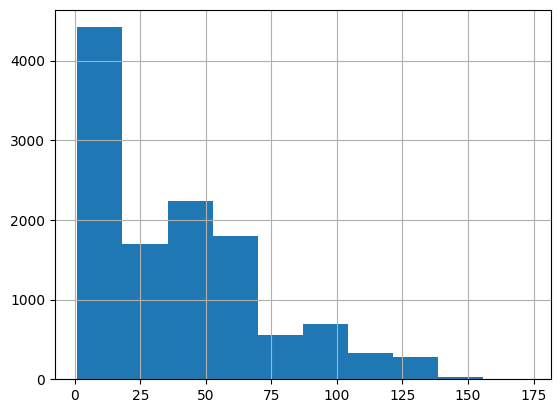

In [ ]:
df["years_of_antiguaty"].hist()

<Axes: >

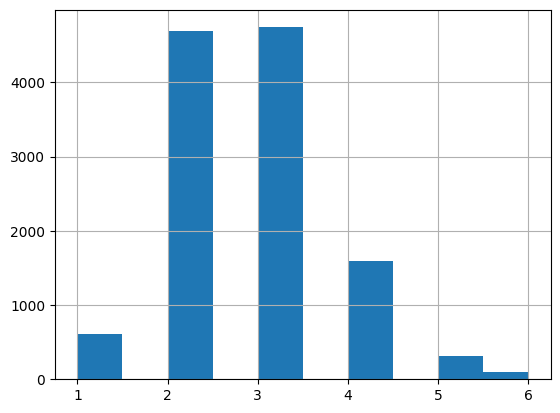

In [ ]:
df["rooms"].hist()

<Axes: >

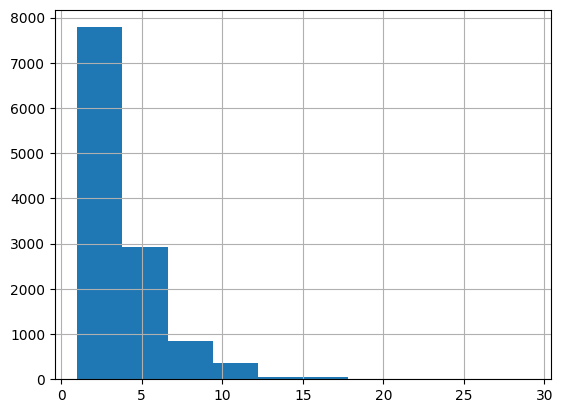

In [ ]:
df["floor"].hist()

<Axes: >

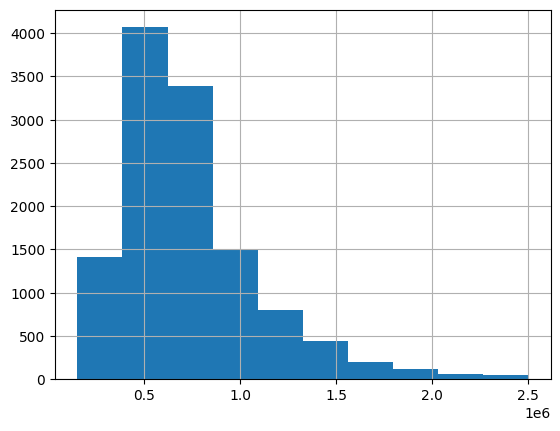

In [ ]:
df["price"].hist()

<Axes: >

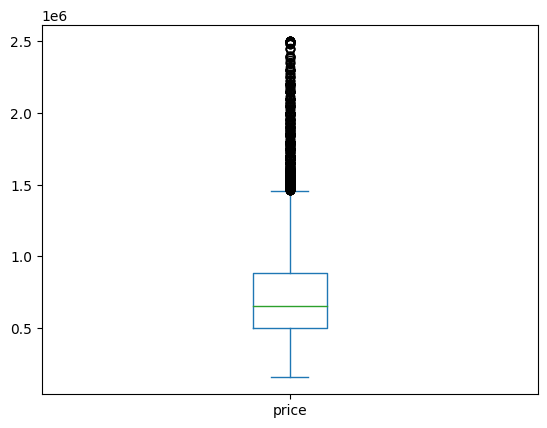

In [ ]:
df["price"].plot(kind="box")

In [ ]:
df["has_parking_space"].value_counts()

has_parking_space
no     8680
yes    3365
Name: count, dtype: int64

In [ ]:
df["has_parking_space"].value_counts(normalize=True)

has_parking_space
no     0.720631
yes    0.279369
Name: proportion, dtype: float64

<Axes: ylabel='count'>

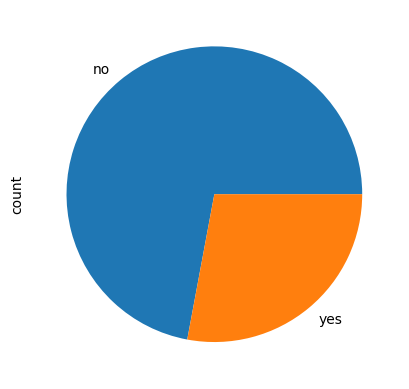

In [ ]:
df["has_parking_space"].value_counts().plot(kind="pie")

In [ ]:
df["city"].value_counts(normalize=True)

city
warszawa       0.326193
krakow         0.160315
gdansk         0.105189
wroclaw        0.101204
lodz           0.068825
lublin         0.039768
gdynia         0.038107
bydgoszcz      0.036613
poznan         0.033956
szczecin       0.024824
radom          0.019510
katowice       0.016106
bialystok      0.015691
rzeszow        0.010793
czestochowa    0.002906
Name: proportion, dtype: float64

<Axes: xlabel='city'>

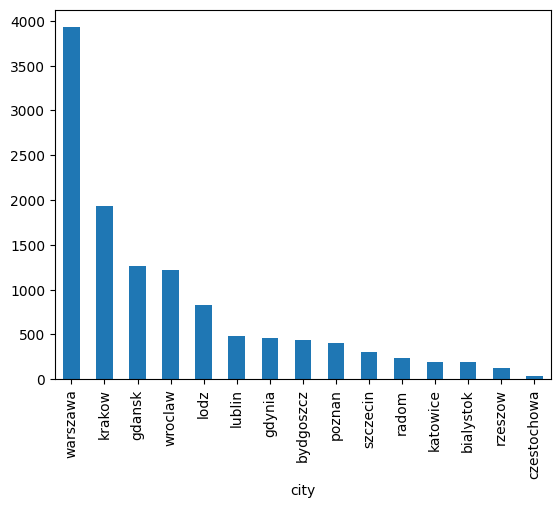

In [ ]:
df["city"].value_counts().plot(kind="bar")

<Axes: xlabel='square_meters', ylabel='price'>

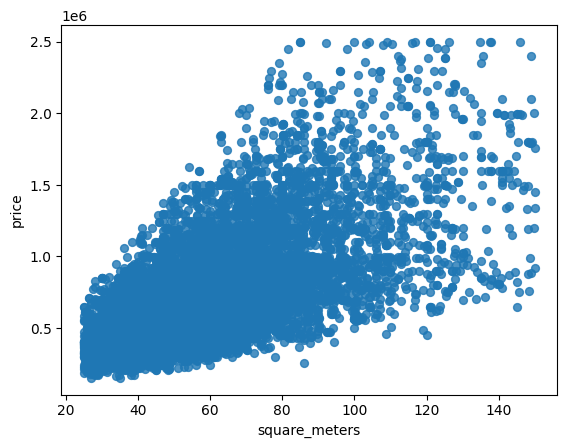

In [ ]:
df.plot(kind='scatter', x='square_meters', y='price', s=32, alpha=.8)

<Axes: xlabel='rooms', ylabel='price'>

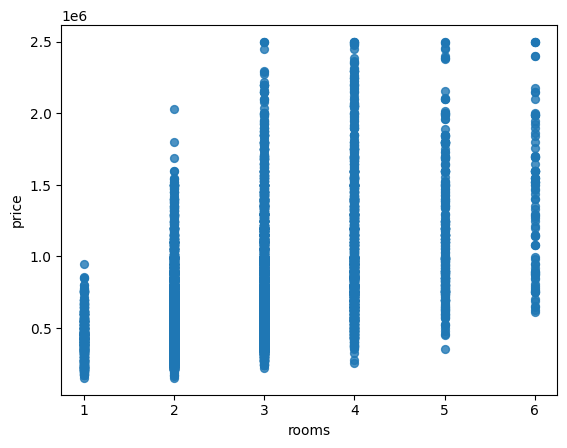

In [ ]:
df.plot(kind='scatter', x='rooms', y='price', s=32, alpha=.8)

<Axes: xlabel='years_of_antiguaty', ylabel='price'>

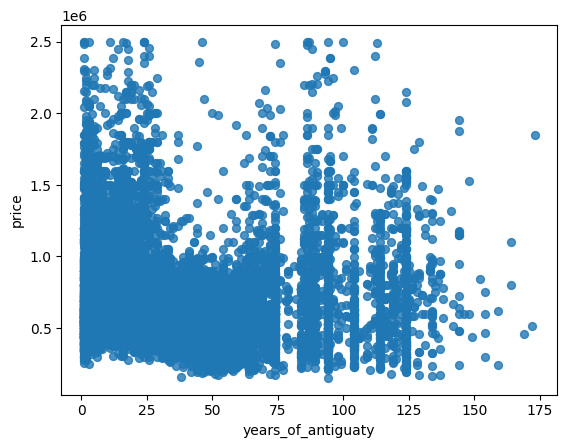

In [ ]:
df.plot(kind='scatter', x='years_of_antiguaty', y='price', s=32, alpha=.8)

<Axes: xlabel='school_distance', ylabel='price'>

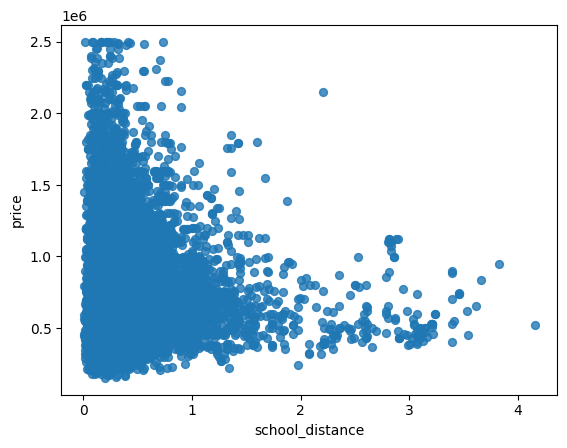

In [ ]:
df.plot(kind='scatter', x='school_distance', y='price', s=32, alpha=.8)

<Axes: xlabel='has_parking_space', ylabel='price'>

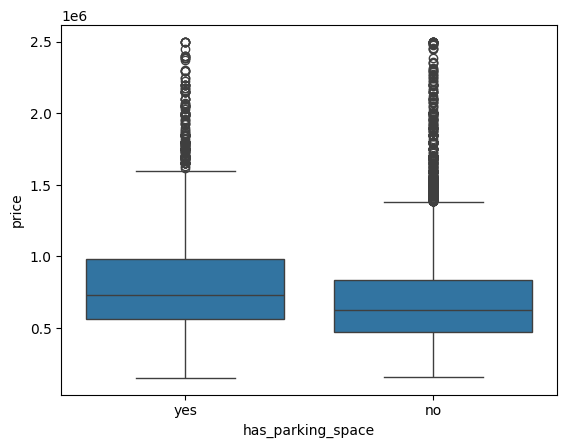

In [ ]:
sns.boxplot(data=df, x='has_parking_space', y='price')

<Axes: xlabel='city', ylabel='price'>

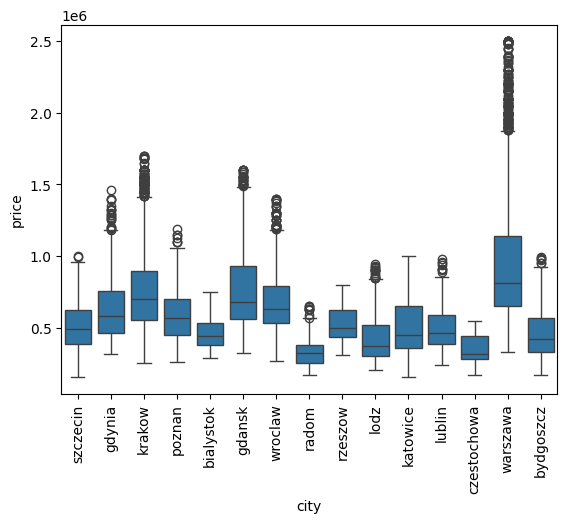

In [ ]:
plt.xticks(rotation=90)
sns.boxplot(data=df, x='city', y='price')

In [ ]:
df.select_dtypes(include="number").corr()

,square_meters,rooms,floor,floor_count,years_of_antiguaty,centre_distance,poi_count,school_distance,clinic_distance,po_distance,kinder_distance,restaurant_distance,college_distance,pharmacy_distance,price
square_meters,1.000000,0.824394,-0.083825,-0.141913,0.001763,0.072046,0.015552,0.064007,0.000275,0.040039,0.054603,0.003789,0.051783,0.041964,0.639703
rooms,0.824394,1.000000,-0.055752,-0.092326,-0.012357,0.074745,-0.026062,0.079410,0.037654,0.053752,0.061811,0.043620,0.070582,0.062027,0.491256
floor,-0.083825,-0.055752,1.000000,0.683010,-0.075703,-0.018180,0.040003,-0.112443,-0.135762,-0.081036,-0.098161,-0.083709,-0.070872,-0.108820,0.012059
floor_count,-0.141913,-0.092326,0.683010,1.000000,-0.139807,-0.030769,0.047531,-0.144289,-0.189112,-0.096628,-0.127506,-0.117945,-0.095758,-0.133378,0.034834
years_of_antiguaty,0.001763,-0.012357,-0.075703,-0.139807,1.000000,-0.346287,0.375131,-0.261663,-0.229516,-0.229972,-0.094375,-0.148209,-0.358329,-0.194141,-0.141084
centre_distance,0.072046,0.074745,-0.018180,-0.030769,-0.346287,1.000000,-0.452580,0.256036,0.402912,0.222194,0.085223,0.199740,0.550803,0.232400,0.076088
poi_count,0.015552,-0.026062,0.040003,0.047531,0.375131,-0.452580,1.000000,-0.326493,-0.375698,-0.342258,-0.219744,-0.376280,-0.450004,-0.328205,0.202869
school_distance,0.064007,0.079410,-0.112443,-0.144289,-0.261663,0.256036,-0.326493,1.000000,0.533048,0.671234,0.719430,0.678072,0.424050,0.727457,-0.016988
clinic_distance,0.000275,0.037654,-0.135762,-0.189112,-0.229516,0.402912,-0.375698,0.533048,1.000000,0.447209,0.397621,0.508447,0.498009,0.484241,-0.155730
po_distance,0.040039,0.053752,-0.081036,-0.096628,-0.229972,0.222194,-0.342258,0.671234,0.447209,1.000000,0.640240,0.687297,0.318791,0.736735,-0.038021


In [ ]:
df["has_parking_space"] = df["has_parking_space"].apply(lambda x: 1 if x == "yes" else 0)
df["has_balcony"] = df["has_balcony"].apply(lambda x: 1 if x == "yes" else 0)
df["has_elevator"] = df["has_elevator"].apply(lambda x: 1 if x == "yes" else 0)
df["has_security"] = df["has_security"].apply(lambda x: 1 if x == "yes" else 0)
df["has_storage_room"] = df["has_storage_room"].apply(lambda x: 1 if x == "yes" else 0)
df["ownership"] = df["ownership"].apply(lambda x: 1 if x == "cooperative" else 0)

In [ ]:
df = df.reset_index(drop=True)

# Scaling & Encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

In [ ]:
categorical_features = X.select_dtypes(include="object").columns
numerical_features = X.select_dtypes(include="number").columns

In [ ]:
encoder = OneHotEncoder()
df_encoded = encoder.fit_transform(X[categorical_features]).toarray()
df_encoded = pd.DataFrame(df_encoded, columns=encoder.get_feature_names_out())
df_encoded

,city_bialystok,city_bydgoszcz,city_czestochowa,city_gdansk,city_gdynia,city_katowice,city_krakow,city_lodz,city_lublin,city_poznan,city_radom,city_rzeszow,city_szczecin,city_warszawa,city_wroclaw,type_apartmentBuilding,type_blockOfFlats,type_tenement,type_unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12040,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
12041,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12042,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12043,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(X[numerical_features])
df_scaled = pd.DataFrame(df_scaled, columns=scaler.get_feature_names_out())
df_scaled

,square_meters,rooms,floor,floor_count,years_of_antiguaty,centre_distance,poi_count,school_distance,clinic_distance,po_distance,kinder_distance,restaurant_distance,college_distance,pharmacy_distance,ownership,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room
0,0.173174,0.314063,-0.534354,-0.469167,-0.363569,0.033217,-0.450544,-0.802144,0.330405,0.584404,-0.227441,2.024387,-0.999557,1.093094,2.781113,1.606081,0.717302,-1.022078,-0.353355,1.019027
1,-0.570395,-0.792044,-0.534354,1.239839,0.333537,-0.505256,-0.096378,-0.165950,-0.665220,-0.608204,-0.221873,-0.216153,0.237381,-0.157829,-0.359568,-0.622634,-1.394112,0.978398,-0.353355,1.019027
2,0.022115,-0.792044,-0.151674,-0.469167,-0.727276,-0.310104,-0.539085,0.462548,-0.187414,-0.439864,0.259725,-0.182205,0.427609,-0.483925,-0.359568,-0.622634,0.717302,0.978398,-0.353355,-0.981328
3,-0.555852,-0.792044,1.761726,1.809507,0.151683,-0.042675,-0.627627,-0.119775,-0.498106,-0.366363,0.440672,-0.161314,0.367537,0.224397,-0.359568,-0.622634,0.717302,0.978398,-0.353355,1.019027
4,0.585539,1.420169,-0.534354,-0.754001,2.879488,-1.116007,0.080705,-0.409653,-0.766430,-0.318943,-0.113305,-0.333663,-0.748346,-0.366316,-0.359568,1.606081,-1.394112,-1.022078,-0.353355,1.019027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12040,1.472661,1.420169,-0.534354,-1.038835,-0.909130,-0.396838,0.036435,0.021317,-0.619322,-0.454090,-0.472416,-0.644414,-0.559028,-0.483925,-0.359568,1.606081,0.717302,0.978398,-0.353355,-0.981328
12041,2.367290,1.420169,-0.534354,-1.038835,4.031228,-1.350911,1.497370,-0.720054,-0.868817,-0.330798,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,-0.622634,-1.394112,-1.022078,-0.353355,-0.981328
12042,2.315217,2.526275,-0.534354,-0.469167,2.909797,-1.350911,1.497370,-0.720054,-0.868817,-0.330798,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,-0.622634,-1.394112,-1.022078,-0.353355,1.019027
12043,1.894877,1.420169,-0.151674,-0.469167,2.273309,-1.350911,1.497370,-0.720054,-0.868817,-0.330798,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,1.606081,0.717302,-1.022078,-0.353355,1.019027


In [ ]:
X = pd.concat([df_encoded, df_scaled], axis=1)
X

,city_bialystok,city_bydgoszcz,city_czestochowa,city_gdansk,city_gdynia,city_katowice,city_krakow,city_lodz,city_lublin,city_poznan,...,kinder_distance,restaurant_distance,college_distance,pharmacy_distance,ownership,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.227441,2.024387,-0.999557,1.093094,2.781113,1.606081,0.717302,-1.022078,-0.353355,1.019027
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.221873,-0.216153,0.237381,-0.157829,-0.359568,-0.622634,-1.394112,0.978398,-0.353355,1.019027
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.259725,-0.182205,0.427609,-0.483925,-0.359568,-0.622634,0.717302,0.978398,-0.353355,-0.981328
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.440672,-0.161314,0.367537,0.224397,-0.359568,-0.622634,0.717302,0.978398,-0.353355,1.019027
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.113305,-0.333663,-0.748346,-0.366316,-0.359568,1.606081,-1.394112,-1.022078,-0.353355,1.019027
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12040,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.472416,-0.644414,-0.559028,-0.483925,-0.359568,1.606081,0.717302,0.978398,-0.353355,-0.981328
12041,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,-0.622634,-1.394112,-1.022078,-0.353355,-0.981328
12042,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,-0.622634,-1.394112,-1.022078,-0.353355,1.019027
12043,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.176211,-0.701864,-0.776562,-0.350279,-0.359568,1.606081,0.717302,-1.022078,-0.353355,1.019027


# Entrenamiento

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:

models = [
  LinearRegression(),
  KNeighborsRegressor(),
  DecisionTreeRegressor(),
  RandomForestRegressor()
]

for model in models:

  model.fit(X_train, y_train)

  y_pred = pd.Series(model.predict(X_test))
  y_pred.index = y_test.index

  print(str(model))
  print("MAE :", mean_absolute_error(y_test, y_pred))
  print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
  print("R2 :", r2_score(y_test, y_pred))

LinearRegression()
MAE : 130558.26359485263
RMSE : 184939.73303521157
R2 : 0.7468108235880209
KNeighborsRegressor()
MAE : 140345.23254462433
RMSE : 203096.00446204733
R2 : 0.6946573696841201
DecisionTreeRegressor()
MAE : 115302.81403071815
RMSE : 194586.66634654536
R2 : 0.719707911907742
RandomForestRegressor()
MAE : 85414.25970960344
RMSE : 135340.70735014512
R2 : 0.8644056582091113


In [ ]:
  y_pred = pd.Series(models[-1].predict(X_test))
  y_pred.index = y_test.index

  results = pd.concat([df.loc[X_test.index], pd.DataFrame(y_pred)], axis=1)
  results.columns = list(df.columns)[:-1] + ["real_price", "predicted_price"]
  results

,city,type,square_meters,rooms,floor,floor_count,years_of_antiguaty,centre_distance,poi_count,school_distance,...,college_distance,pharmacy_distance,ownership,has_parking_space,has_balcony,has_elevator,has_security,has_storage_room,real_price,predicted_price
9739,warszawa,blockOfFlats,47.80,2.0,5.0,6.0,1.0,10.56,2.0,0.922,...,4.047,0.959,0,0,1,1,0,0,570000,646471.23
1244,krakow,tenement,54.20,2.0,1.0,5.0,95.0,1.93,27.0,0.344,...,0.627,0.134,0,0,0,1,0,0,850000,819597.62
3600,gdansk,unknown,51.50,3.0,4.0,4.0,64.0,8.29,14.0,0.387,...,0.975,0.188,0,0,1,0,0,0,545000,627037.90
9196,warszawa,blockOfFlats,62.90,3.0,2.0,6.0,18.0,3.11,18.0,0.348,...,0.470,0.572,0,0,1,1,1,0,1290000,1110503.20
4064,gdansk,apartmentBuilding,30.00,1.0,3.0,6.0,4.0,1.01,23.0,0.138,...,0.366,0.071,0,0,0,1,0,0,595000,587457.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,szczecin,blockOfFlats,46.60,2.0,9.0,11.0,54.0,3.10,6.0,0.337,...,1.423,0.253,1,0,1,1,0,1,399000,365190.00
4125,gdansk,apartmentBuilding,50.20,2.0,3.0,3.0,12.0,0.21,142.0,0.182,...,0.555,0.218,0,0,1,1,1,0,1154800,902508.22
9058,warszawa,unknown,87.00,3.0,3.0,4.0,16.0,10.17,7.0,0.649,...,1.903,0.095,0,0,1,1,0,0,1599000,1230185.12
849,krakow,apartmentBuilding,49.87,2.0,3.0,7.0,2.0,4.44,12.0,0.270,...,1.253,0.299,0,0,1,1,0,0,690000,739924.70


<Axes: xlabel='real_price', ylabel='predicted_price'>

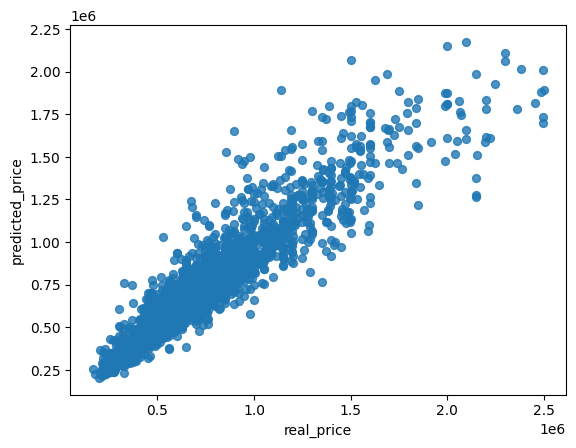

In [ ]:
results.plot(kind='scatter', x='real_price', y='predicted_price', s=32, alpha=.8)

In [ ]:
feature_importances = pd.concat([pd.DataFrame(models[0].feature_names_in_), pd.DataFrame(models[0].coef_)], axis=1)
feature_importances.columns = ["feature", "coef_"]
feature_importances.sort_values(by="coef_", ascending=False)

,feature,coef_
13,city_warszawa,1.576999e+17
3,city_gdansk,1.576999e+17
6,city_krakow,1.576999e+17
4,city_gdynia,1.576999e+17
14,city_wroclaw,1.576999e+17
9,city_poznan,1.576999e+17
8,city_lublin,1.576999e+17
11,city_rzeszow,1.576999e+17
7,city_lodz,1.576999e+17
0,city_bialystok,1.576999e+17


In [ ]:
feature_importances = pd.concat([pd.DataFrame(models[-1].feature_names_in_), pd.DataFrame(models[-1].feature_importances_)], axis=1)
feature_importances.columns = ["feature", "importance"]
feature_importances.sort_values(by="importance", ascending=False)

,feature,importance
19,square_meters,0.430598
13,city_warszawa,0.168474
24,centre_distance,0.085670
23,years_of_antiguaty,0.071636
6,city_krakow,0.035013
3,city_gdansk,0.024398
25,poi_count,0.022274
27,clinic_distance,0.020533
31,college_distance,0.015634
14,city_wroclaw,0.014667


In [ ]:
import pickle

with open("model.pkl", "wb") as file:
  pickle.dump(models[-1], file)